<a href="https://colab.research.google.com/github/Nikesh5005/ML_PROJ/blob/main/Dynamic__Pricing_Engine_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/retail_store_inventory.csv")
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring


In [ ]:
df=df.drop(labels=['Demand Forecast'],axis=1)


In [ ]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,73.64,0,Sunny,0,68.95,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,73.73,20,Snowy,0,72.45,Winter
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,82.57,10,Cloudy,0,83.78,Autumn
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,11.11,10,Rainy,0,10.91,Winter
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,53.14,20,Rainy,0,55.80,Spring


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Price               73100 non-null  float64
 9   Discount            73100 non-null  int64  
 10  Weather Condition   73100 non-null  object 
 11  Holiday/Promotion   73100 non-null  int64  
 12  Competitor Pricing  73100 non-null  float64
 13  Seasonality         73100 non-null  object 
dtypes: float64(2), int64(5), object(7)
memory usage: 7.8+ MB


In [ ]:
df['Date']=pd.to_datetime(df['Date'])

In [ ]:
df['Date_Month']=df['Date'].dt.month_name()

In [ ]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Date_Month
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,33.50,20,Rainy,0,29.69,Autumn,January
1,2022-01-01,S001,P0002,Toys,South,204,150,66,63.01,20,Sunny,0,66.16,Autumn,January
2,2022-01-01,S001,P0003,Toys,West,102,65,51,27.99,10,Sunny,1,31.32,Summer,January
3,2022-01-01,S001,P0004,Toys,North,469,61,164,32.72,10,Cloudy,1,34.74,Autumn,January
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,73.64,0,Sunny,0,68.95,Summer,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,73.73,20,Snowy,0,72.45,Winter,January
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,82.57,10,Cloudy,0,83.78,Autumn,January
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,11.11,10,Rainy,0,10.91,Winter,January
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,53.14,20,Rainy,0,55.80,Spring,January


In [ ]:
df['Days_of_week']=df['Date'].dt.day_name()

In [ ]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Date_Month,Days_of_week
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,33.50,20,Rainy,0,29.69,Autumn,January,Saturday
1,2022-01-01,S001,P0002,Toys,South,204,150,66,63.01,20,Sunny,0,66.16,Autumn,January,Saturday
2,2022-01-01,S001,P0003,Toys,West,102,65,51,27.99,10,Sunny,1,31.32,Summer,January,Saturday
3,2022-01-01,S001,P0004,Toys,North,469,61,164,32.72,10,Cloudy,1,34.74,Autumn,January,Saturday
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,73.64,0,Sunny,0,68.95,Summer,January,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,73.73,20,Snowy,0,72.45,Winter,January,Monday
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,82.57,10,Cloudy,0,83.78,Autumn,January,Monday
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,11.11,10,Rainy,0,10.91,Winter,January,Monday
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,53.14,20,Rainy,0,55.80,Spring,January,Monday


In [ ]:
df["is_weekend"] = df["Days_of_week"].apply(lambda x: 1 if x in ["Saturday", "Sunday"] else 0)

In [ ]:
df["is_month_end"] = df["Date"].dt.is_month_end.astype(int)

In [ ]:
df['Product ID'].value_counts()
df['Store ID'].unique()

array(['S001', 'S002', 'S003', 'S004', 'S005'], dtype=object)

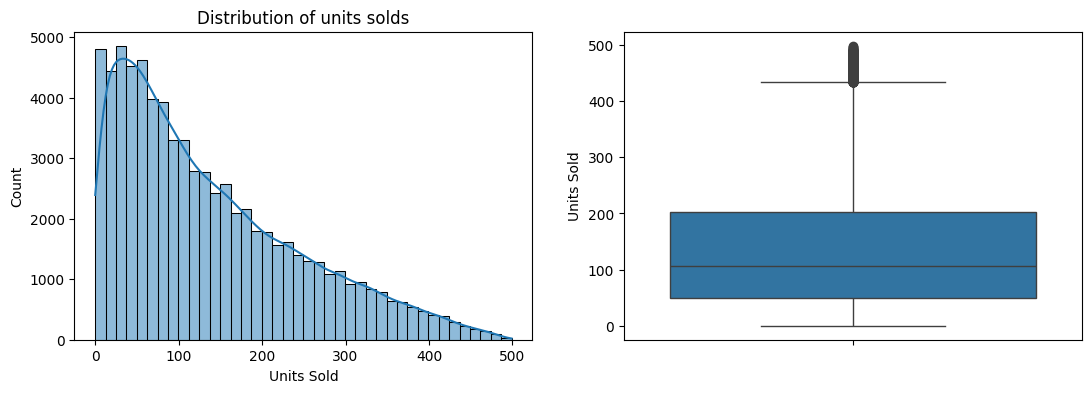

In [ ]:
plt.figure(figsize=(13,4))
plt.subplot(1,2,1)
sns.histplot(data=df,x='Units Sold',bins=40,kde=True)
plt.title("Distribution of units solds")
plt.subplot(1,2,2)
sns.boxplot(data=df, y='Units Sold')
plt.show()

can clearly see that the unite sold column is right skewed with high varience with standared daviation of 108 where the median is 107

In [ ]:
df['Units Sold'].describe()

,Units Sold
count,73100.000000
mean,136.464870
std,108.919406
min,0.000000
25%,49.000000
50%,107.000000
75%,203.000000
max,499.000000


# product sold  most including all the store

In [ ]:
df.groupby( 'Product ID')['Units Sold'].sum().sort_values(ascending=False)

,Units Sold
Product ID,
P0016,508472
P0020,507708
P0014,507622
P0015,507283
P0005,503648
P0009,502086
P0013,500619
P0017,500510
P0011,499362


In [ ]:
## top 3 product per store
top_2 = (
    df.groupby(['Store ID', 'Product ID'])['Units Sold']
      .sum()
      .reset_index()
      .sort_values(['Store ID', 'Units Sold'], ascending=[True, False])
      .groupby('Store ID')
      .head(2)
)

print(top_2)

   Store ID Product ID  Units Sold
2      S001      P0003      103393
3      S001      P0004      103001
20     S002      P0001      105999
28     S002      P0009      105376
52     S003      P0013      107479
44     S003      P0005      105408
75     S004      P0016      104777
73     S004      P0014      103904
94     S005      P0015      109099
82     S005      P0003      105667


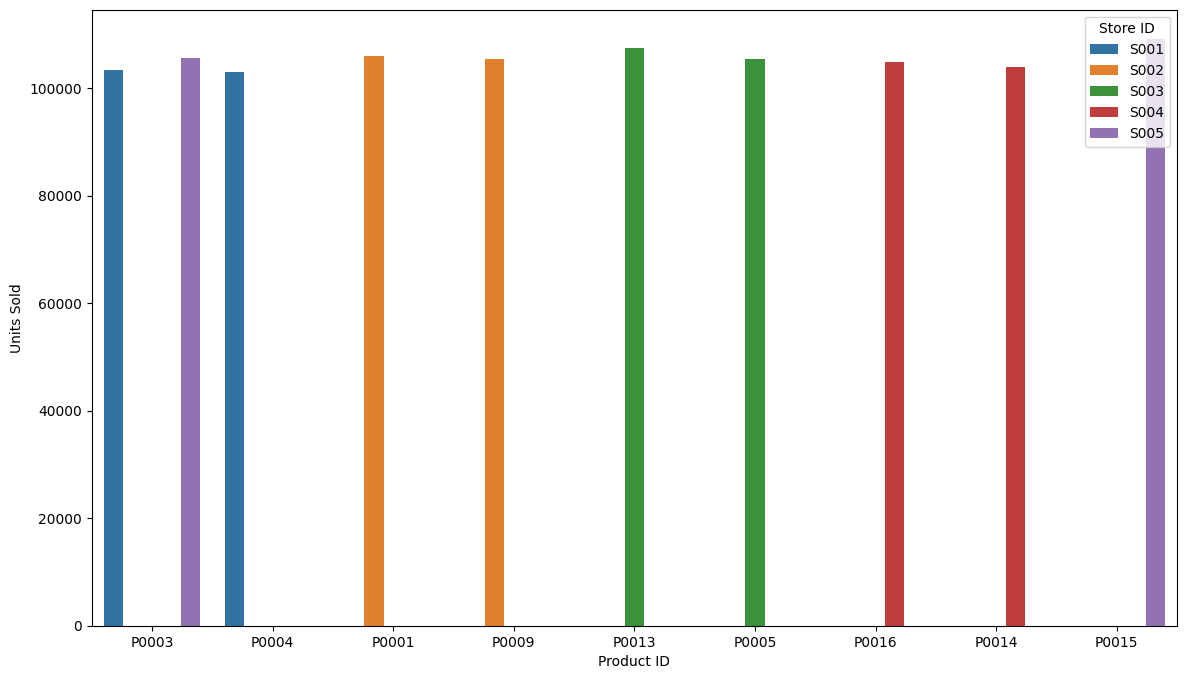

In [ ]:

plt.figure(figsize=(14,8))
sns.barplot(data=top_2, x='Product ID',y='Units Sold',hue='Store ID')
plt.show()

The top-selling product varies across stores, indicating that different stores have different best-performing products. However, the sales volumes of these top products are quite similar, suggesting that no single store significantly outperforms the others in terms of its best-selling product

In [ ]:
df['Revenue'] = df['Units Sold'] * df['Price'] * (1 - df['Discount'] / 100)

## Store generatiing highest Revenue

In [ ]:
pd.set_option('display.float_format', '{:,.0f}'.format)
df.groupby('Store ID')[['Revenue', 'Units Sold']].sum()

,Revenue,Units Sold
Store ID,,
S001,"97,426,189",1975750
S002,"98,950,004",1987715
S003,"100,034,402",2022696
S004,"98,057,140",1979245
S005,"100,503,639",2010176


In [ ]:
grouped=df.groupby('Store ID')[['Revenue', 'Units Sold']].sum().sort_values( by='Units Sold', ascending=False)
print(grouped)

             Revenue  Units Sold
Store ID                        
S003     100,034,402     2022696
S005     100,503,639     2010176
S002      98,950,004     1987715
S004      98,057,140     1979245
S001      97,426,189     1975750


<Axes: ylabel='Store ID'>

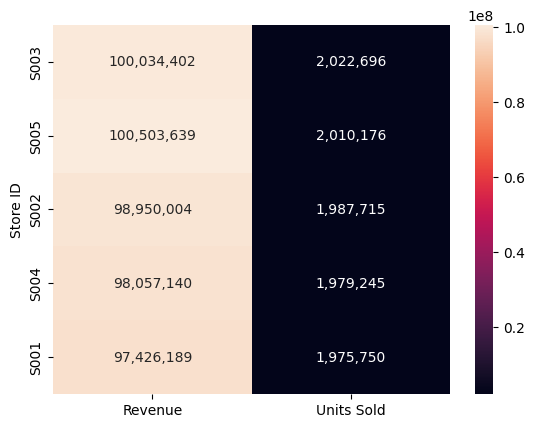

In [ ]:

sns.heatmap(data=grouped, annot=True,fmt=",.0f")

In [ ]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Date_Month,Days_of_week,is_weekend,is_month_end,Revenue
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,34,20,Rainy,0,30,Autumn,January,Saturday,1,0,"3,404"
1,2022-01-01,S001,P0002,Toys,South,204,150,66,63,20,Sunny,0,66,Autumn,January,Saturday,1,0,"7,561"
2,2022-01-01,S001,P0003,Toys,West,102,65,51,28,10,Sunny,1,31,Summer,January,Saturday,1,0,"1,637"
3,2022-01-01,S001,P0004,Toys,North,469,61,164,33,10,Cloudy,1,35,Autumn,January,Saturday,1,0,"1,796"
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,74,0,Sunny,0,69,Summer,January,Saturday,1,0,"1,031"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,74,20,Snowy,0,72,Winter,January,Monday,0,0,472
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,83,10,Cloudy,0,84,Autumn,January,Monday,0,0,"3,790"
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,11,10,Rainy,0,11,Winter,January,Monday,0,0,360
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,53,20,Rainy,0,56,Spring,January,Monday,0,0,"11,223"


In [ ]:
df=df.drop(labels=['Revenue'],axis=1)

In [ ]:
numeric_column=df.select_dtypes(include='number').columns.to_list()
numeric_column

['Inventory Level',
 'Units Sold',
 'Units Ordered',
 'Price',
 'Discount',
 'Holiday/Promotion',
 'Competitor Pricing',
 'is_weekend',
 'is_month_end']

In [ ]:
pd.reset_option('display.float_format')
corr=df[numeric_column].corr()['Units Sold']
corr

,Units Sold
Inventory Level,0.589995
Units Sold,1.000000
Units Ordered,-0.000930
Price,0.001082
Discount,0.002576
Holiday/Promotion,-0.000374
Competitor Pricing,0.001259
is_weekend,-0.002348
is_month_end,-0.001661


Here we can see that Inventory Level have a positive 0.5 corelation with the target column 	Units Sold which can be a good pradictor for the target column


<Axes: xlabel='Units Sold', ylabel='Inventory Level'>

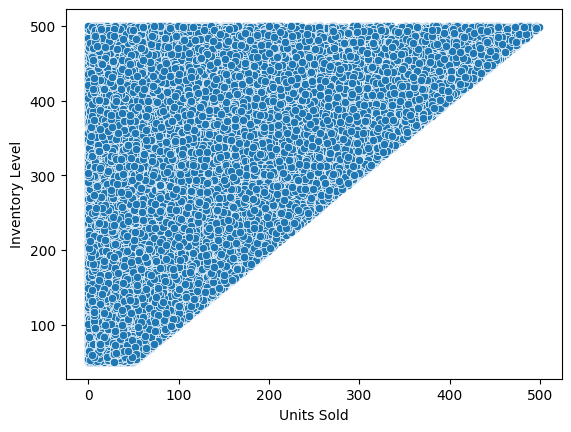

In [ ]:
sns.scatterplot(data=df, x='Units Sold',y='Inventory Level')

<Axes: xlabel='Units Sold', ylabel='Inventory Level'>

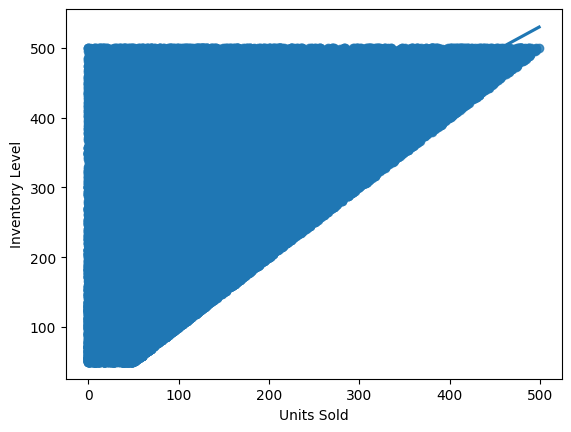

In [ ]:
sns.regplot(data=df, x='Units Sold',y='Inventory Level')